In [227]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [228]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
heart_disease = fetch_ucirepo(id=45) 
  
# data (as pandas dataframes) 
X = heart_disease.data.features 
y = heart_disease.data.targets 
  
# metadata 
print(heart_disease.metadata) 
  
# variable information 
print(heart_disease.variables) 


{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

In [229]:
import pandas as pd

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
df = pd.read_csv(url, header=None)

In [230]:
import pandas as pd

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
df = pd.read_csv(url, header=None)

print(df.shape)
print(df.head())

(303, 14)
     0    1    2      3      4    5    6      7    8    9    10   11   12  13
0  63.0  1.0  1.0  145.0  233.0  1.0  2.0  150.0  0.0  2.3  3.0  0.0  6.0   0
1  67.0  1.0  4.0  160.0  286.0  0.0  2.0  108.0  1.0  1.5  2.0  3.0  3.0   2
2  67.0  1.0  4.0  120.0  229.0  0.0  2.0  129.0  1.0  2.6  2.0  2.0  7.0   1
3  37.0  1.0  3.0  130.0  250.0  0.0  0.0  187.0  0.0  3.5  3.0  0.0  3.0   0
4  41.0  0.0  2.0  130.0  204.0  0.0  2.0  172.0  0.0  1.4  1.0  0.0  3.0   0


In [231]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       303 non-null    float64
 1   1       303 non-null    float64
 2   2       303 non-null    float64
 3   3       303 non-null    float64
 4   4       303 non-null    float64
 5   5       303 non-null    float64
 6   6       303 non-null    float64
 7   7       303 non-null    float64
 8   8       303 non-null    float64
 9   9       303 non-null    float64
 10  10      303 non-null    float64
 11  11      303 non-null    str    
 12  12      303 non-null    str    
 13  13      303 non-null    int64  
dtypes: float64(11), int64(1), str(2)
memory usage: 33.3 KB


In [232]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [233]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [234]:
# -------------------------
# 1. Dataset Structure
# -------------------------
def dataset_overview(df):
    print("=" * 50)
    print("DATASET OVERVIEW")
    print("=" * 50)

    print(f"Shape: {df.shape}")
    print("\nColumn Names:")
    print(df.columns.tolist())

    print("\nData Types:")
    print(df.dtypes)

    print("\nMissing Values:")
    print(df.isnull().sum())

    print("\nDuplicate Rows:")
    print(df.duplicated().sum())

    print("\nFirst 5 Rows:")
    display(df.head())


# -------------------------
# 2. Summary Statistics
# -------------------------
def summary_statistics(df):
    print("=" * 50)
    print("SUMMARY STATISTICS")
    print("=" * 50)

    display(df.describe(include='all'))


# -------------------------
# 3. Numerical Distributions
# -------------------------
def plot_numeric_distributions(df):
    numeric_cols = df.select_dtypes(include=np.number).columns

    for col in numeric_cols:
        plt.figure(figsize=(6,4))
        plt.hist(df[col].dropna(), bins=20)
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.show()


# -------------------------
# 4. Categorical Distributions
# -------------------------
def plot_categorical_distributions(df):
    categorical_cols = df.select_dtypes(exclude=np.number).columns

    for col in categorical_cols:
        plt.figure(figsize=(8,4))
        df[col].value_counts().plot(kind='bar')
        plt.title(f"Distribution of {col}")
        plt.ylabel("Count")
        plt.show()


# -------------------------
# 5. Correlation Analysis
# -------------------------
def correlation_analysis(df):
    numeric_df = df.select_dtypes(include=np.number)

    corr = numeric_df.corr()

    plt.figure(figsize=(10,8))
    plt.imshow(corr, aspect='auto')
    plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.title("Correlation Matrix")
    plt.tight_layout()
    plt.show()

    return corr


# -------------------------
# 6. Outlier Detection
# -------------------------
def detect_outliers(df):
    numeric_cols = df.select_dtypes(include=np.number).columns

    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        outliers = df[
            (df[col] < Q1 - 1.5 * IQR) |
            (df[col] > Q3 + 1.5 * IQR)
        ]

        print(f"{col}: {len(outliers)} outliers")


# -------------------------
# 7. Target Variable Analysis
# -------------------------
def target_distribution(df, target_col):
    print(df[target_col].value_counts())

    plt.figure(figsize=(6,4))
    df[target_col].value_counts().plot(kind='bar')
    plt.title(f"Target Distribution: {target_col}")
    plt.ylabel("Count")
    plt.show()


# -------------------------
# 8. Run Full EDA
# -------------------------
def run_eda(df, target_col=None):
    dataset_overview(df)
    summary_statistics(df)

    plot_numeric_distributions(df)
    plot_categorical_distributions(df)

    correlation_analysis(df)
    detect_outliers(df)

    if target_col:
        target_distribution(df, target_col)

DATASET OVERVIEW
Shape: (303, 14)

Column Names:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]

Data Types:
0     float64
1     float64
2     float64
3     float64
4     float64
5     float64
6     float64
7     float64
8     float64
9     float64
10    float64
11        str
12        str
13      int64
dtype: object

Missing Values:
0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
dtype: int64

Duplicate Rows:
0

First 5 Rows:


,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


SUMMARY STATISTICS


,0,1,2,3,4,5,6,7,8,9,10,11,12,13
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303,303,303.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,4,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,3.0,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,176,166,NaN
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,NaN,NaN,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,NaN,NaN,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,NaN,NaN,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,NaN,NaN,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,NaN,NaN,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,NaN,NaN,2.000000


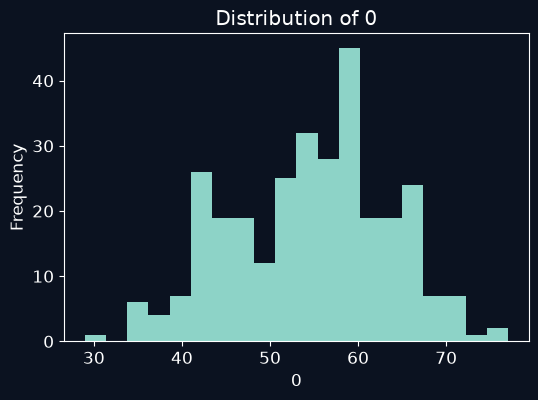

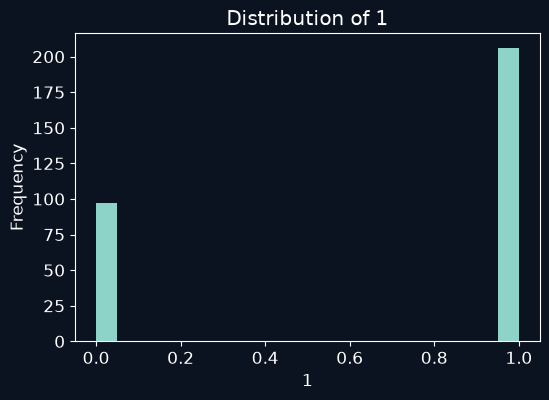

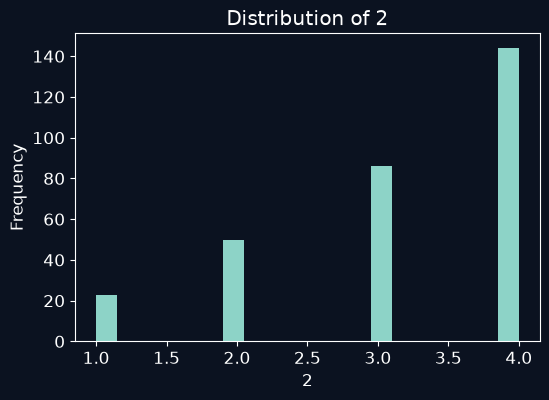

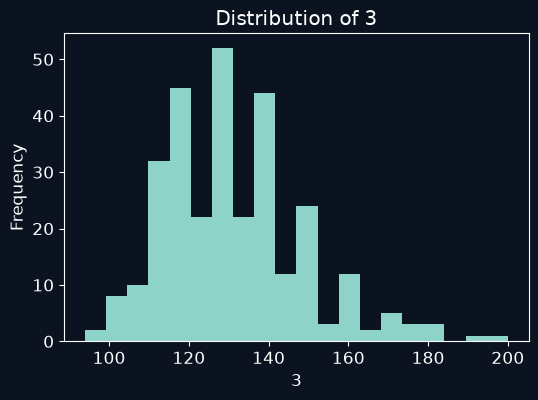

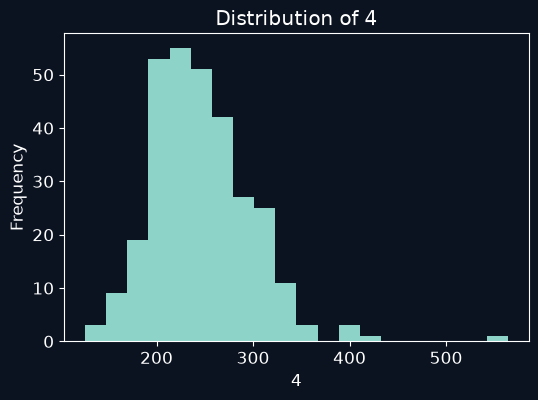

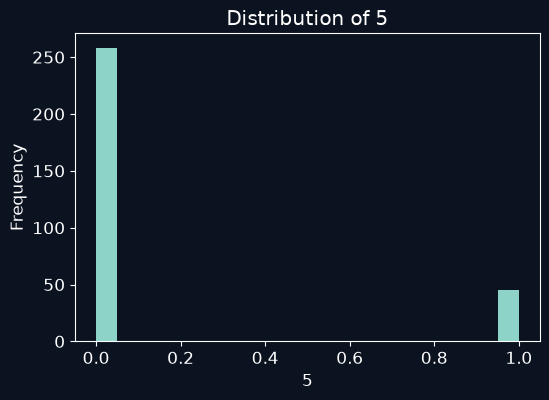

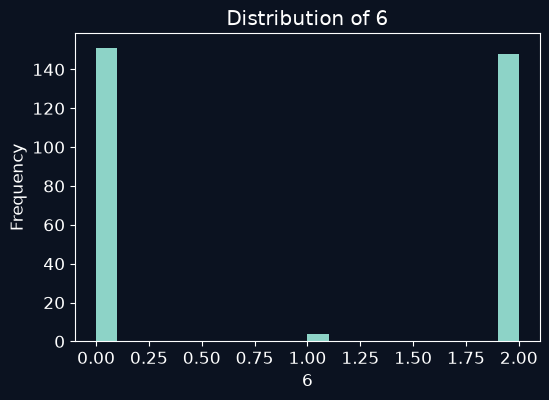

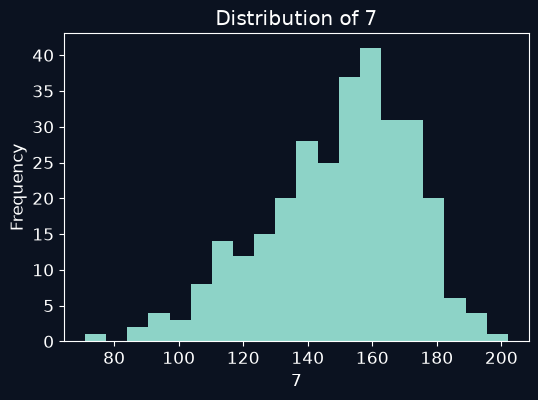

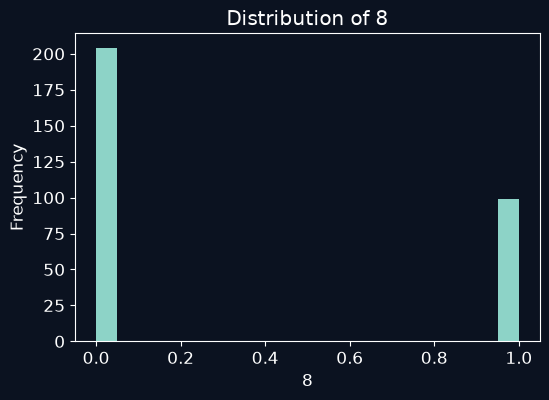

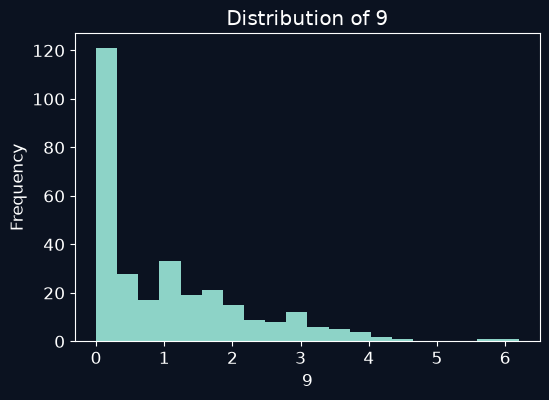

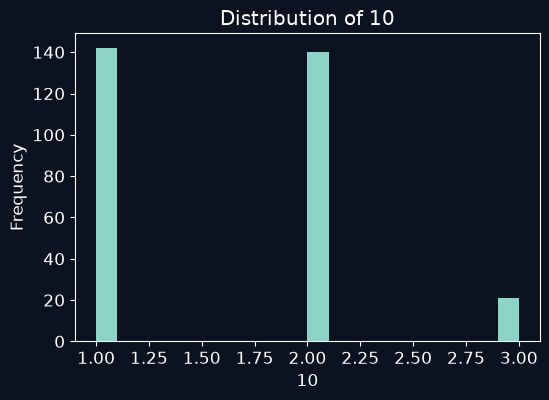

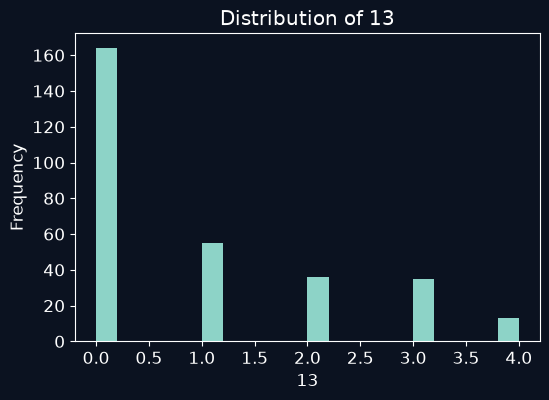

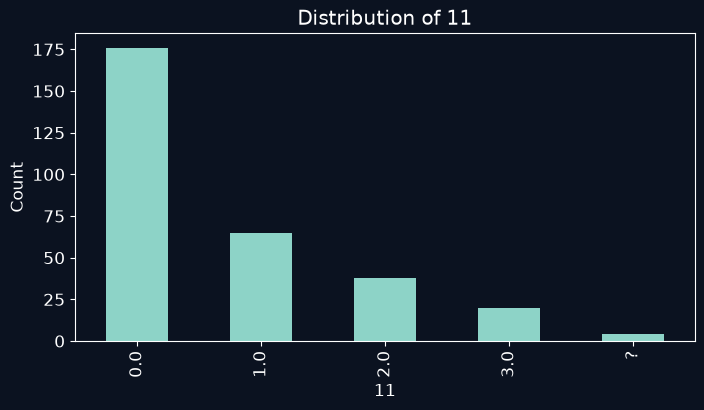

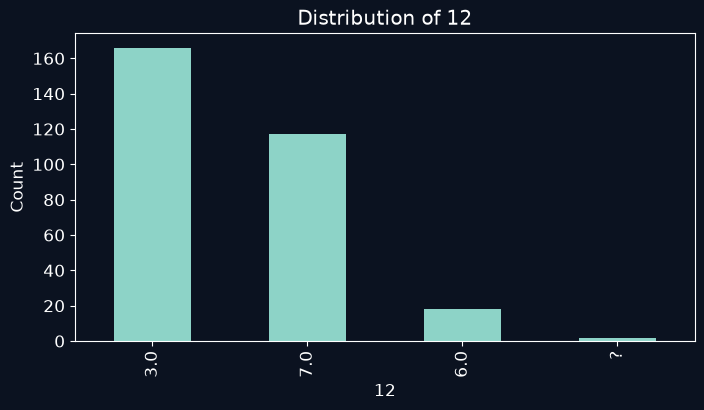

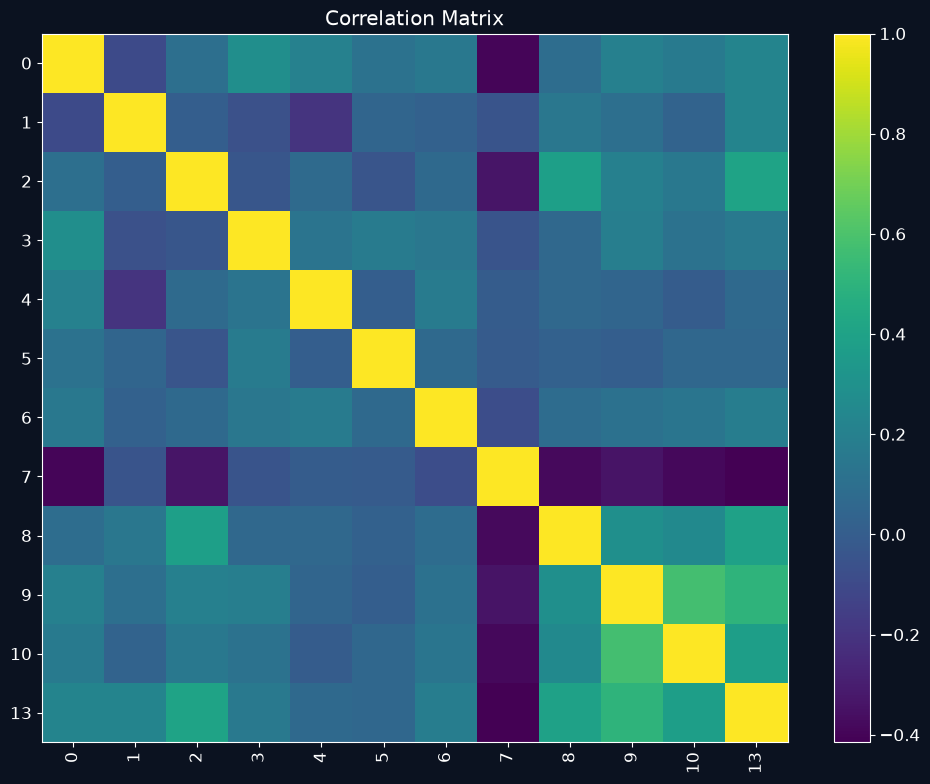

0: 0 outliers
1: 0 outliers
2: 23 outliers
3: 9 outliers
4: 5 outliers
5: 45 outliers
6: 0 outliers
7: 1 outliers
8: 0 outliers
9: 5 outliers
10: 0 outliers
13: 0 outliers


In [235]:
run_eda(df)

In [236]:
columns = [
    "age",
    "sex",
    "chest_pain_type",
    "resting_blood_pressure",
    "cholesterol",
    "fasting_blood_sugar",
    "rest_ecg",
    "max_heart_rate",
    "exercise_induced_angina",
    "st_depression",
    "slope",
    "num_major_vessels",
    "thal",
    "target"
]

In [237]:
df.columns = columns

In [238]:
df.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,rest_ecg,max_heart_rate,exercise_induced_angina,st_depression,slope,num_major_vessels,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [239]:
df = df.replace("?", np.nan)
df = df.astype(float)

DATASET OVERVIEW
Shape: (303, 14)

Column Names:
['age', 'sex', 'chest_pain_type', 'resting_blood_pressure', 'cholesterol', 'fasting_blood_sugar', 'rest_ecg', 'max_heart_rate', 'exercise_induced_angina', 'st_depression', 'slope', 'num_major_vessels', 'thal', 'target']

Data Types:
age                        float64
sex                        float64
chest_pain_type            float64
resting_blood_pressure     float64
cholesterol                float64
fasting_blood_sugar        float64
rest_ecg                   float64
max_heart_rate             float64
exercise_induced_angina    float64
st_depression              float64
slope                      float64
num_major_vessels          float64
thal                       float64
target                     float64
dtype: object

Missing Values:
age                        0
sex                        0
chest_pain_type            0
resting_blood_pressure     0
cholesterol                0
fasting_blood_sugar        0
rest_ecg               

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,rest_ecg,max_heart_rate,exercise_induced_angina,st_depression,slope,num_major_vessels,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0.0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2.0
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1.0
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0.0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0.0


SUMMARY STATISTICS


,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,rest_ecg,max_heart_rate,exercise_induced_angina,st_depression,slope,num_major_vessels,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


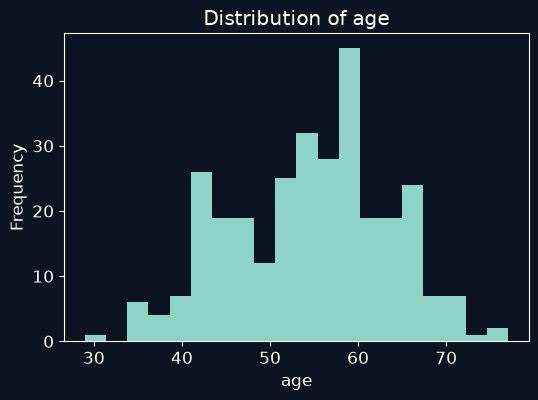

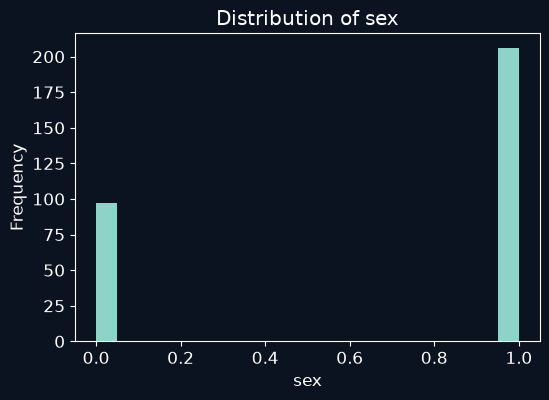

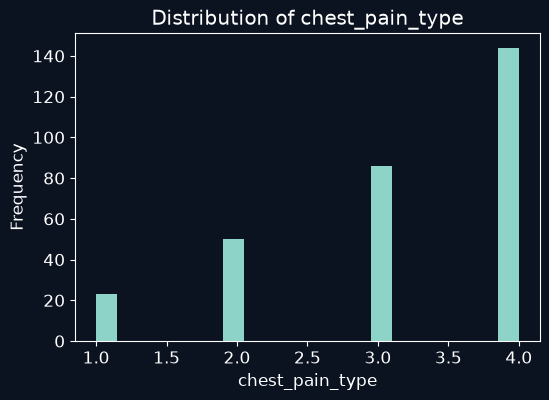

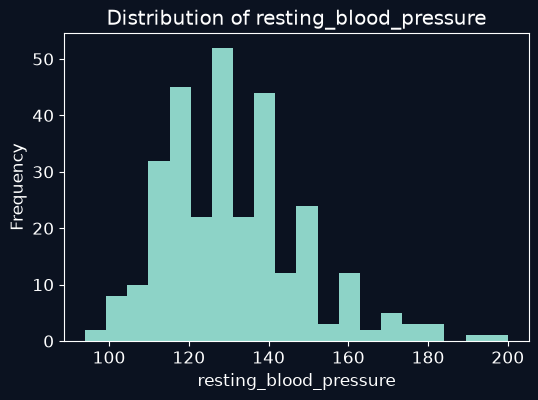

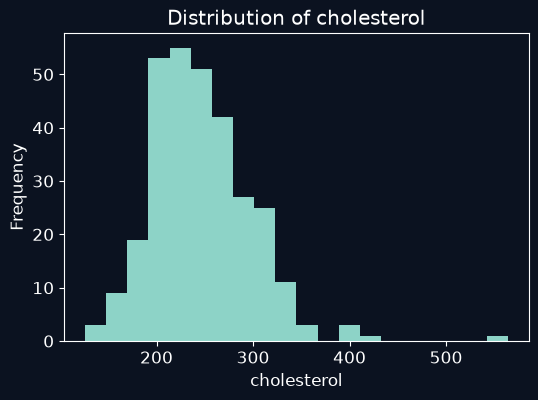

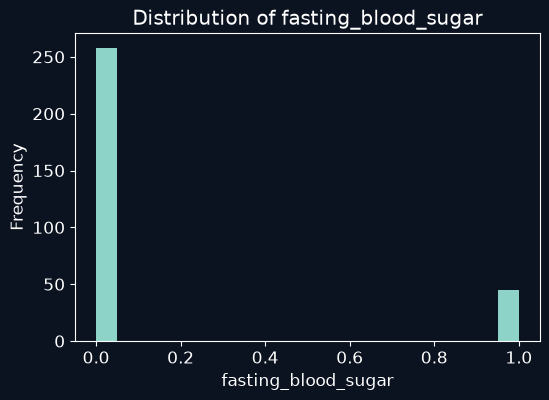

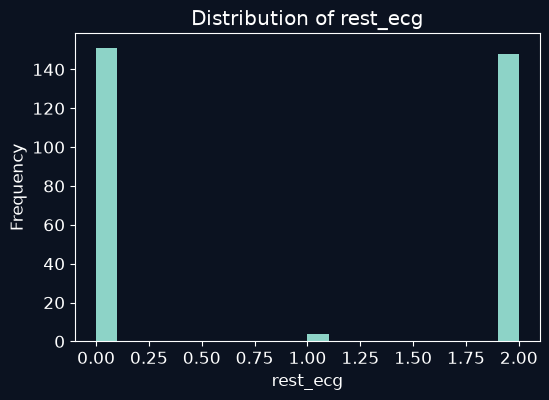

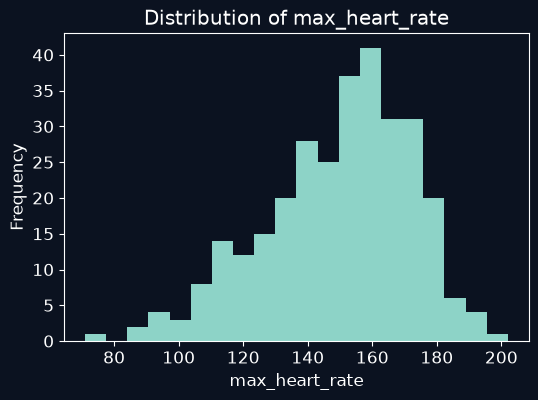

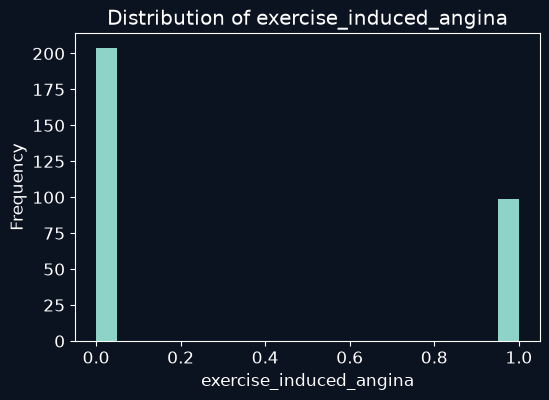

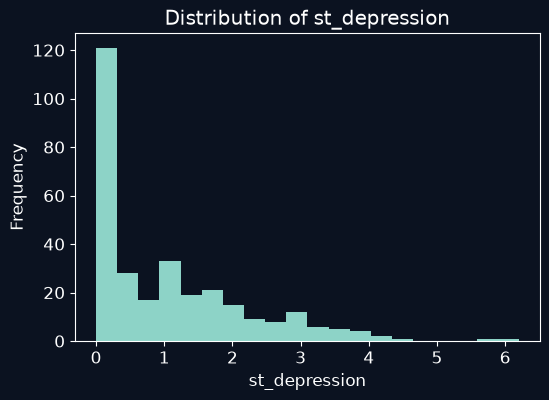

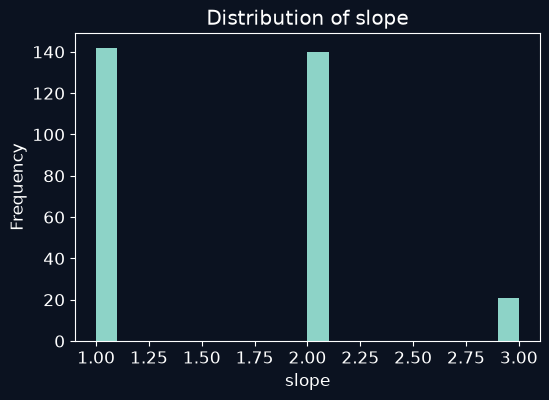

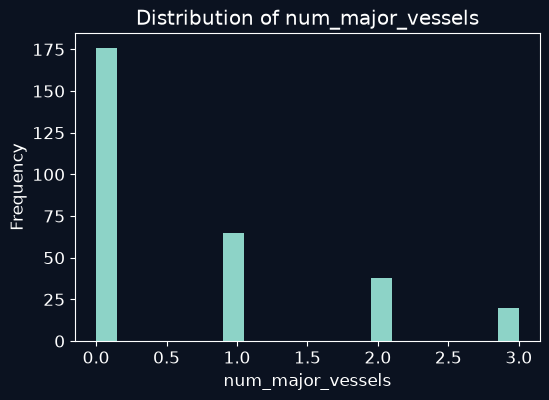

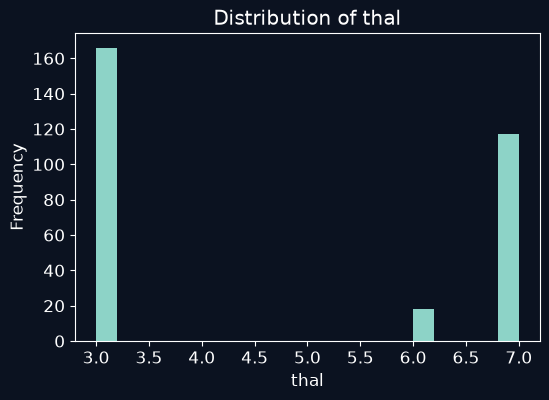

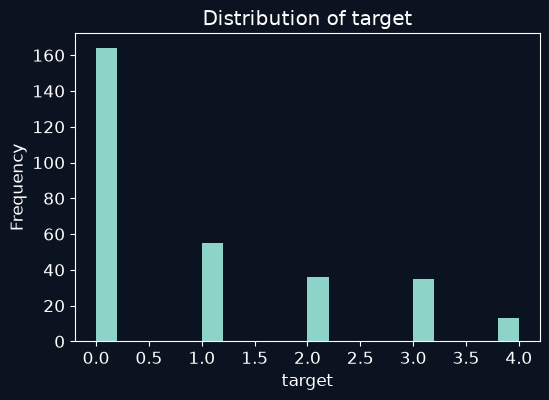

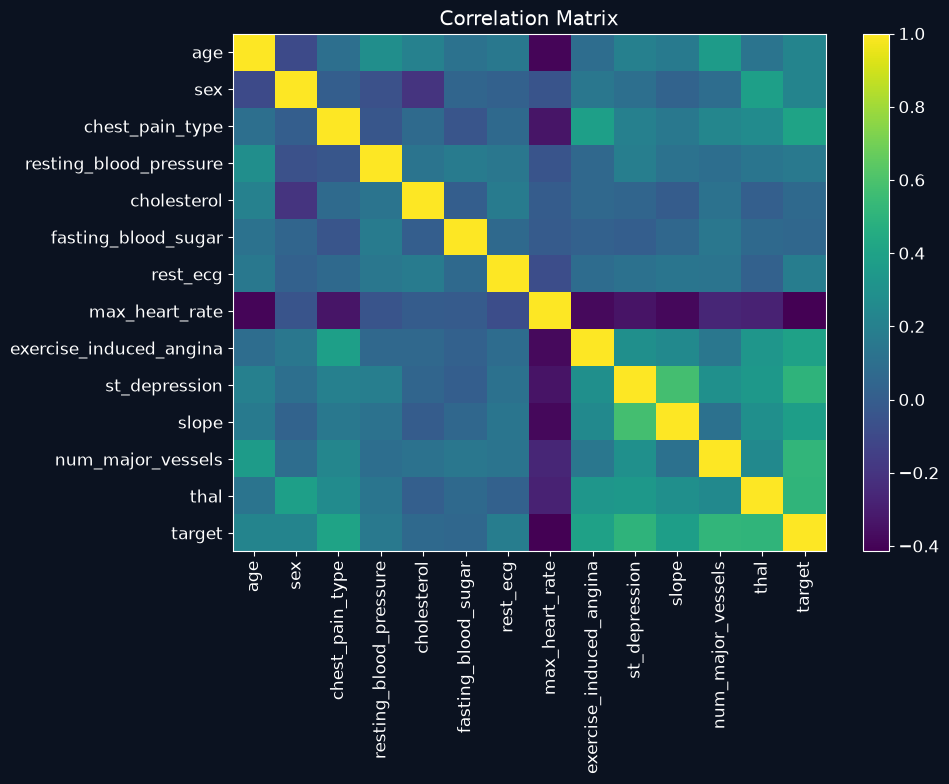

age: 0 outliers
sex: 0 outliers
chest_pain_type: 23 outliers
resting_blood_pressure: 9 outliers
cholesterol: 5 outliers
fasting_blood_sugar: 45 outliers
rest_ecg: 0 outliers
max_heart_rate: 1 outliers
exercise_induced_angina: 0 outliers
st_depression: 5 outliers
slope: 0 outliers
num_major_vessels: 20 outliers
thal: 0 outliers
target: 0 outliers
target
0.0    164
1.0     55
2.0     36
3.0     35
4.0     13
Name: count, dtype: int64


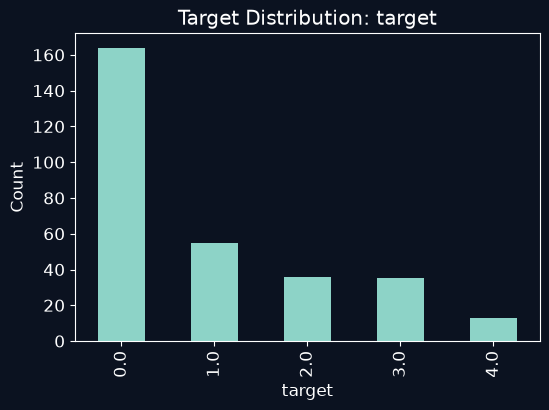

In [240]:
run_eda(df, target_col="target")

In [241]:
import pandas as pd
import numpy as np

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

df = pd.read_csv(url, header=None)

# Column names
df.columns = [
    "age","sex","chest_pain_type","resting_blood_pressure","cholesterol",
    "fasting_blood_sugar","rest_ecg","max_heart_rate",
    "exercise_induced_angina","st_depression","slope",
    "num_major_vessels","thal","target"
]

# Replace missing values ("?") with NaN
df = df.replace("?", np.nan)

# Convert everything to numeric
df = df.astype(float)

# Fill missing values (simple approach)
df = df.fillna(df.median())

In [242]:
df["target"] = df["target"].apply(lambda x: 1 if x > 0 else 0)

In [243]:
from sklearn.model_selection import train_test_split

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [244]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [245]:
from sklearn.model_selection import train_test_split

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [246]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [247]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

print("LOGISTIC REGRESSION RESULTS")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

LOGISTIC REGRESSION RESULTS
Accuracy: 0.8852459016393442
              precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61



In [248]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("RANDOM FOREST RESULTS")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

RANDOM FOREST RESULTS
Accuracy: 0.8688524590163934
              precision    recall  f1-score   support

           0       0.84      0.90      0.87        29
           1       0.90      0.84      0.87        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



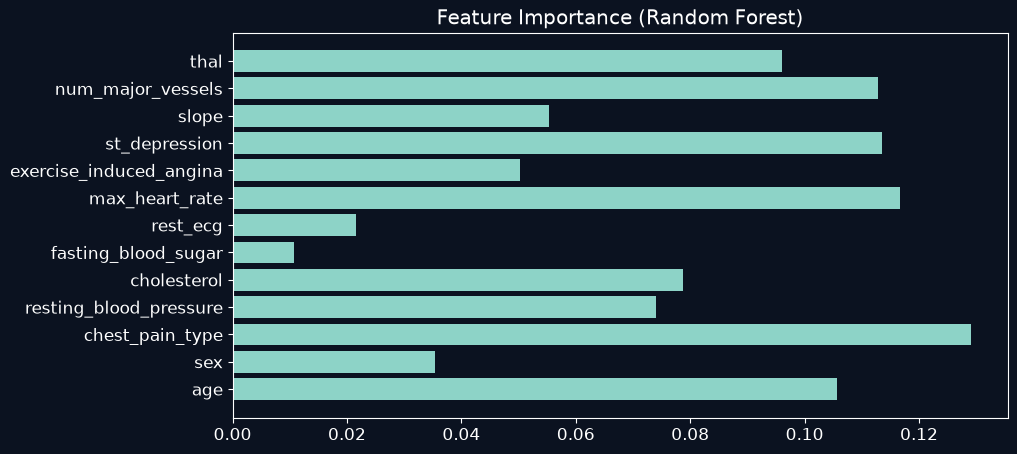

In [249]:
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_
features = X.columns

plt.figure(figsize=(10,5))
plt.barh(features, importances)
plt.title("Feature Importance (Random Forest)")
plt.show()

In [250]:
# To find the disease prevalence
df["target"] = df["target"].apply(lambda x: 1 if x > 0 else 0)

In [251]:
def prevalence_by_age(df):
    age_bins = [0, 40, 50, 60, 70, 100]
    age_labels = ["<40", "40-49", "50-59", "60-69", "70+"]

    temp = df.copy()
    temp["age_group"] = pd.cut(
        temp["age"],
        bins=age_bins,
        labels=age_labels
    )

    prevalence = (
        temp.groupby("age_group")["target"]
        .mean()
        .mul(100)
        .round(2)
    )

    print("Disease prevalence by age group (%)")
    print(prevalence)

    return prevalence

In [252]:
prevalence_by_age(df)

Disease prevalence by age group (%)
age_group
<40      33.33
40-49    30.26
50-59    50.77
60-69    58.90
70+      16.67
Name: target, dtype: float64


age_group
<40      33.33
40-49    30.26
50-59    50.77
60-69    58.90
70+      16.67
Name: target, dtype: float64

In [253]:
#Conclusion: As humans age, the risk for cardiovasular disease increases

In [254]:
#0 = female; 1 = male
def prevalence_by_sex(df):
    prevalence = (
        df.groupby("sex")["target"]
        .mean()
        .mul(100)
        .round(2)
    )

    prevalence.index = ["Female", "Male"]

    print("Disease prevalence by sex (%)")
    print(prevalence)

    return prevalence

In [255]:
prevalence_by_sex(df)

Disease prevalence by sex (%)
Female    25.77
Male      55.34
Name: target, dtype: float64


Female    25.77
Male      55.34
Name: target, dtype: float64

In [256]:
#Male have higher chances of getting cardiovascular disease

In [257]:
def prevalence_by_cholesterol(df):
    temp = df.copy()

    temp["chol_group"] = pd.qcut(
        temp["cholesterol"],
        q=4,
        labels=["Low", "Medium", "High", "Very High"]
    )

    prevalence = (
        temp.groupby("chol_group")["target"]
        .mean()
        .mul(100)
        .round(2)
    )

    print("Disease prevalence by cholesterol quartile (%)")
    print(prevalence)

    return prevalence

In [258]:
prevalence_by_cholesterol(df)

Disease prevalence by cholesterol quartile (%)
chol_group
Low          37.66
Medium       41.33
High         47.37
Very High    57.33
Name: target, dtype: float64


chol_group
Low          37.66
Medium       41.33
High         47.37
Very High    57.33
Name: target, dtype: float64

In [259]:
#Cholesterol is a risk factor for cardiovascular disease

In [260]:
def correlation_structure(df):
    corr = df.corr(numeric_only=True)

    target_corr = (
        corr["target"]
        .sort_values(ascending=False)
    )

    print("Correlation with Heart Disease Target")
    print(target_corr)

    return corr

In [261]:
corr_matrix = correlation_structure(df)

Correlation with Heart Disease Target
target                     1.000000
thal                       0.522057
num_major_vessels          0.460033
exercise_induced_angina    0.431894
st_depression              0.424510
chest_pain_type            0.414446
slope                      0.339213
sex                        0.276816
age                        0.223120
rest_ecg                   0.169202
resting_blood_pressure     0.150825
cholesterol                0.085164
fasting_blood_sugar        0.025264
max_heart_rate            -0.417167
Name: target, dtype: float64


In [262]:
#Correlation analysis shows that people with higher heart rate have lower chances of heart disease. People with problems in their blood vessels have higher chances of heart disease

In [263]:
def class_balance(df):
    counts = df["target"].value_counts()
    percentages = (
        df["target"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )

    print("Class Counts")
    print(counts)

    print("\nClass Percentages")
    print(percentages)

    return counts, percentages

In [264]:
class_balance(df)

Class Counts
target
0    164
1    139
Name: count, dtype: int64

Class Percentages
target
0    54.13
1    45.87
Name: proportion, dtype: float64


(target
 0    164
 1    139
 Name: count, dtype: int64,
 target
 0    54.13
 1    45.87
 Name: proportion, dtype: float64)

In [265]:
def clinical_eda_report(df):
    print("\n=== AGE PREVALENCE ===")
    prevalence_by_age(df)

    print("\n=== SEX PREVALENCE ===")
    prevalence_by_sex(df)

    print("\n=== CHOLESTEROL PREVALENCE ===")
    prevalence_by_cholesterol(df)

    print("\n=== CORRELATION STRUCTURE ===")
    correlation_structure(df)

    print("\n=== CLASS BALANCE ===")
    class_balance(df)

In [266]:
clinical_eda_report(df)


=== AGE PREVALENCE ===
Disease prevalence by age group (%)
age_group
<40      33.33
40-49    30.26
50-59    50.77
60-69    58.90
70+      16.67
Name: target, dtype: float64

=== SEX PREVALENCE ===
Disease prevalence by sex (%)
Female    25.77
Male      55.34
Name: target, dtype: float64

=== CHOLESTEROL PREVALENCE ===
Disease prevalence by cholesterol quartile (%)
chol_group
Low          37.66
Medium       41.33
High         47.37
Very High    57.33
Name: target, dtype: float64

=== CORRELATION STRUCTURE ===
Correlation with Heart Disease Target
target                     1.000000
thal                       0.522057
num_major_vessels          0.460033
exercise_induced_angina    0.431894
st_depression              0.424510
chest_pain_type            0.414446
slope                      0.339213
sex                        0.276816
age                        0.223120
rest_ecg                   0.169202
resting_blood_pressure     0.150825
cholesterol                0.085164
fasting_blood_s

In [267]:
print(df.shape)
print(df.columns)

(303, 14)
Index(['age', 'sex', 'chest_pain_type', 'resting_blood_pressure',
       'cholesterol', 'fasting_blood_sugar', 'rest_ecg', 'max_heart_rate',
       'exercise_induced_angina', 'st_depression', 'slope',
       'num_major_vessels', 'thal', 'target'],
      dtype='str')


In [268]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# -------------------------
# Prepare Data
# -------------------------

# Make a copy
heart_df = df.copy()

# Replace ? with NaN if present
heart_df = heart_df.replace("?", np.nan)

# Convert all columns to numeric
heart_df = heart_df.apply(lambda col: col.astype(float))

# Fill missing values with median
heart_df = heart_df.fillna(heart_df.median())

# Convert target to binary
heart_df["target"] = np.where(heart_df["target"] > 0, 1, 0)

# Features and target
X = heart_df.drop("target", axis=1)
y = heart_df["target"]

# -------------------------
# Train/Test Split
# -------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# -------------------------
# Scale Features
# -------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -------------------------
# Train Logistic Regression
# -------------------------

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

# -------------------------
# Predictions
# -------------------------

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# -------------------------
# Results
# -------------------------

print("Accuracy:")
print(accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nROC AUC:")
print(roc_auc_score(y_test, y_prob))

Accuracy:
0.8688524590163934

Confusion Matrix:
[[27  6]
 [ 2 26]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61


ROC AUC:
0.9512987012987013


In [269]:
# The Logistic Regression model achieved an accuracy of 86.9% and an ROC-AUC score of 0.951, indicating excellent predictive performance. The model correctly identified 93% of patients with heart disease, resulting in only two false negative cases. Since false negatives represent patients whose disease would be missed, the low number of false negatives is particularly important from a clinical perspective. The high ROC-AUC demonstrates that the model effectively distinguishes between patients with and without heart disease across different classification thresholds

In [270]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"],
    "class_weight": [None, "balanced"]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring="roc_auc"
)

grid.fit(X_train_scaled, y_train)

print("Best Parameters:")
print(grid.best_params_)

best_log_model = grid.best_estimator_

Best Parameters:
{'C': 0.1, 'class_weight': 'balanced', 'solver': 'liblinear'}


In [271]:
from sklearn.linear_model import LogisticRegression

best_log_model = LogisticRegression(
    C=0.1,
    class_weight="balanced",
    solver="liblinear",
    max_iter=1000,
    random_state=42
)

best_log_model.fit(X_train_scaled, y_train)

y_pred = best_log_model.predict(X_test_scaled)
y_prob = best_log_model.predict_proba(X_test_scaled)[:, 1]

In [272]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.8688524590163934

Confusion Matrix:
[[27  6]
 [ 2 26]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61


ROC-AUC: 0.9567099567099567


In [273]:
#After hyperparameter tuning, the Logistic Regression model maintained an accuracy of 86.9% while improving its ROC-AUC score to 0.957. This indicates improved ability to distinguish between patients with and without heart disease across classification thresholds. Importantly, the model maintained a high recall of 93% for the positive class, meaning it successfully identifies most patients with heart disease while keeping false negatives low, which is critical in medical diagnosis.

In [274]:
%pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [275]:
from imblearn.over_sampling import SMOTE

# Create SMOTE object
smote = SMOTE(random_state=42)

# Resample training data only
X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Original training shape:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Original training shape:
target
0    131
1    111
Name: count, dtype: int64

After SMOTE:
target
1    131
0    131
Name: count, dtype: int64


In [276]:
from sklearn.linear_model import LogisticRegression

smote_model = LogisticRegression(
    C=0.1,
    class_weight="balanced",
    solver="liblinear",
    max_iter=1000,
    random_state=42
)

smote_model.fit(X_train_smote, y_train_smote)

,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penaltie

In [277]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

y_pred_smote = smote_model.predict(X_test_scaled)
y_prob_smote = smote_model.predict_proba(X_test_scaled)[:,1]

print("Accuracy:")
print(accuracy_score(y_test, y_pred_smote))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_smote))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_smote))

print("\nROC-AUC:")
print(roc_auc_score(y_test, y_prob_smote))

Accuracy:
0.8688524590163934

Confusion Matrix:
[[27  6]
 [ 2 26]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61


ROC-AUC:
0.9534632034632036


In [278]:
comparison = {
    "Model": [
        "Optimized Logistic Regression",
        "SMOTE Logistic Regression"
    ],
    "Accuracy": [
        0.8689,  # replace with actual if different
        accuracy_score(y_test, y_pred_smote)
    ],
    "ROC_AUC": [
        0.9567,  # your current model
        roc_auc_score(y_test, y_prob_smote)
    ]
}

pd.DataFrame(comparison)

,Model,Accuracy,ROC_AUC
0,Optimized Logistic Regression,0.868900,0.956700
1,SMOTE Logistic Regression,0.868852,0.953463


In [279]:
#A SMOTE oversampling experiment was conducted to investigate whether balancing the training data would improve classification performance. The optimized Logistic Regression model achieved an ROC-AUC of 0.957, whereas the SMOTE-enhanced model achieved an ROC-AUC of 0.953. Accuracy remained unchanged at approximately 86.9%. Because the original dataset was already relatively balanced, synthetic oversampling did not provide a measurable benefit and slightly reduced discriminative performance. Therefore, the optimized Logistic Regression model without SMOTE was retained as the preferred model.

In [280]:
print(confusion_matrix(y_test, y_pred_smote))
print(classification_report(y_test, y_pred_smote))

[[27  6]
 [ 2 26]]
              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



In [281]:
#A SMOTE oversampling experiment was performed to evaluate whether balancing the training data would improve predictive performance. The resulting model produced an identical confusion matrix and classification metrics to the optimized Logistic Regression model. Accuracy remained at 86.9%, recall for the disease class remained at 93%, and the number of false negatives remained two cases. Additionally, ROC-AUC decreased slightly from 0.957 to 0.953. These results indicate that SMOTE did not provide a measurable improvement, likely because the original dataset was already relatively balanced. Therefore, the optimized Logistic Regression model without SMOTE was selected for further analysis.

In [282]:
#The next improvements should come from:

More expressive models (Random Forest, XGBoost)
Feature engineering
Hyperparameter tuning
Threshold optimization

SyntaxError: invalid syntax (1768906179.py, line 3)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print(grid_rf.best_params_)

In [ ]:
best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

In [ ]:
from imblearn.over_sampling import SMOTE

# Create SMOTE object
smote = SMOTE(random_state=42)

# Apply SMOTE ONLY to the training set
X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Class distribution before SMOTE:")
print(y_train.value_counts())

print("\nClass distribution after SMOTE:")
print(y_train_smote.value_counts())

In [ ]:
from sklearn.linear_model import LogisticRegression

smote_model = LogisticRegression(
    C=0.1,
    solver="liblinear",
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

smote_model.fit(X_train_smote, y_train_smote)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

y_pred_smote = smote_model.predict(X_test_scaled)
y_prob_smote = smote_model.predict_proba(X_test_scaled)[:,1]

print("Accuracy:")
print(accuracy_score(y_test, y_pred_smote))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_smote))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_smote))

print("\nROC-AUC:")
print(roc_auc_score(y_test, y_prob_smote))

In [ ]:
from sklearn.metrics import recall_score

# Recall before SMOTE
recall_before = recall_score(y_test, y_pred)

# Recall after SMOTE
recall_after = recall_score(y_test, y_pred_smote)

print(f"Recall before SMOTE : {recall_before:.3f}")
print(f"Recall after SMOTE  : {recall_after:.3f}")

In [ ]:
cm_before = confusion_matrix(y_test, y_pred)
cm_after = confusion_matrix(y_test, y_pred_smote)

fn_before = cm_before[1, 0]
fn_after = cm_after[1, 0]

print(f"False Negatives before SMOTE : {fn_before}")
print(f"False Negatives after SMOTE  : {fn_after}")

In [ ]:
comparison = {
    "Metric": [
        "Accuracy",
        "Recall (Disease)",
        "ROC-AUC",
        "False Negatives"
    ],
    "Before SMOTE": [
        accuracy_score(y_test, y_pred),
        recall_before,
        roc_auc_score(y_test, y_prob),
        fn_before
    ],
    "After SMOTE": [
        accuracy_score(y_test, y_pred_smote),
        recall_after,
        roc_auc_score(y_test, y_prob_smote),
        fn_after
    ]
}

comparison_df = pd.DataFrame(comparison)
comparison_df

In [ ]:
The SMOTE oversampling experiment did not improve the predictive performance of the Logistic Regression classifier. Accuracy remained unchanged at 86.9%, while recall for the disease class remained 92.9%, indicating no improvement in identifying patients with heart disease. Furthermore, the number of false negatives remained at two cases, suggesting that oversampling did not reduce clinically important misclassifications. The ROC-AUC score decreased slightly from 0.957 to 0.953, indicating a small reduction in the model's overall discriminative ability. These findings suggest that SMOTE was unnecessary for this dataset because the original class distribution was already relatively balanced.

In [ ]:
%pip install scikit-learn

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# Neural Network
nn_model = MLPClassifier(
    hidden_layer_sizes=(32,16),
    activation='relu',
    solver='adam',
    max_iter=2000,
    random_state=42
)

nn_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_nn = nn_model.predict(X_test_scaled)
y_prob_nn = nn_model.predict_proba(X_test_scaled)[:,1]

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_nn))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_nn))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nn))

print("\nROC-AUC:")
print(roc_auc_score(y_test, y_prob_nn))

In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Optimized Logistic Regression",
        "Neural Network"
    ],
    "Accuracy": [
        0.8689,
        accuracy_score(y_test, y_pred_nn)
    ],
    "ROC_AUC": [
        0.9567,
        roc_auc_score(y_test, y_prob_nn)
    ]
})

comparison

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Logistic Regression
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob)

# Neural Network
fpr_nn, tpr_nn, _ = roc_curve(y_test, y_prob_nn)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_log,
    tpr_log,
    label=f"Logistic Regression (AUC={roc_auc_score(y_test,y_prob):.3f})"
)

plt.plot(
    fpr_nn,
    tpr_nn,
    label=f"Neural Network (AUC={roc_auc_score(y_test,y_prob_nn):.3f})"
)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    "hidden_layer_sizes": [
        (16,),
        (32,),
        (64,),
        (32,16),
        (64,32),
        (64,32,16)
    ],
    "activation": ["relu", "tanh"],
    "alpha": [0.0001, 0.001, 0.01],
    "learning_rate_init": [0.001, 0.01],
    "solver": ["adam"],
    "max_iter": [2000]
}

grid_nn = GridSearchCV(
    estimator=MLPClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_nn.fit(X_train_scaled, y_train)

print("Best Parameters:")
print(grid_nn.best_params_)

print("\nBest Cross Validation ROC-AUC:")
print(grid_nn.best_score_)

In [ ]:
best_nn = grid_nn.best_estimator_

best_nn.fit(X_train_scaled, y_train)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

y_pred_nn = best_nn.predict(X_test_scaled)
y_prob_nn = best_nn.predict_proba(X_test_scaled)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_nn))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_nn))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nn))

print("\nROC-AUC:", roc_auc_score(y_test, y_prob_nn))

In [ ]:
best_nn = MLPClassifier(
    hidden_layer_sizes=(64,32),
    activation="relu",
    alpha=0.001,
    learning_rate_init=0.001,
    max_iter=3000,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=42
)

best_nn.fit(X_train_scaled, y_train)

In [ ]:
comparison = {
    "Model": [
        "Optimized Logistic Regression",
        "Optimized Neural Network"
    ],
    "Accuracy": [
        0.8689,
        accuracy_score(y_test, y_pred_nn)
    ],
    "ROC-AUC": [
        0.9567,
        roc_auc_score(y_test, y_prob_nn)
    ]
}

pd.DataFrame(comparison)

In [ ]:
import joblib

joblib.dump(nn_model, "heart_nn_model.pkl")
joblib.dump(scaler, "heart_scaler.pkl")

In [ ]:
def predict_heart_disease(patient_data):
    """
    patient_data = list of 13 feature values
    """

    scaled = scaler.transform([patient_data])

    prediction = nn_model.predict(scaled)[0]
    probability = nn_model.predict_proba(scaled)[0,1]

    print(f"Risk Probability: {probability:.2%}")

    if prediction == 1:
        print("⚠️ High Risk of Heart Disease")
    else:
        print("✅ Low Risk of Heart Disease")

In [ ]:
sample_patient = X.iloc[0].tolist()

predict_heart_disease(sample_patient)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def variable_information_table(df):

    info = pd.DataFrame({
        "Variable": df.columns,
        "Data Type": df.dtypes.astype(str),
        "Missing Values": df.isnull().sum().values,
        "Unique Values": df.nunique().values
    })

    fig_height = max(4, len(info) * 0.4)

    fig, ax = plt.subplots(figsize=(10, fig_height))
    ax.axis("off")

    table = ax.table(
        cellText=info.values,
        colLabels=info.columns,
        cellLoc="center",
        loc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1.2, 1.8)

    # Apple-style neutral colors
    header_color = "#D9E2EC"
    even_color = "#F8F9FA"
    odd_color = "#FFFFFF"
    edge_color = "#C8CDD3"

    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor(edge_color)

        if row == 0:
            cell.set_facecolor(header_color)
            cell.set_text_props(weight='bold', color="#1F2937")
        else:
            cell.set_facecolor(even_color if row % 2 == 0 else odd_color)
            cell.set_text_props(color="#374151")

    plt.title("Variable Information", fontsize=18, weight='bold', pad=20)

    plt.savefig(
        "variable_information.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    return info

In [ ]:
variable_information_table(df)

In [ ]:
import matplotlib.pyplot as plt

def class_balance_figure(df, target_col):
    """
    Creates a presentation-ready class balance figure.
    Assumes:
        0 = Healthy
        1 = Heart Disease
    """

    counts = df[target_col].value_counts().sort_index()

    labels = ["Healthy", "Heart Disease"]
    values = [counts.get(0, 0), counts.get(1, 0)]

    fig, ax = plt.subplots(figsize=(8,5))

    colors = ["#D9E2EC", "#5B8DEF"]   # Apple-style light gray-blue and blue

    bars = ax.bar(labels, values, color=colors, width=0.55)

    # Add values on top
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 2,
            f"{int(height)}",
            ha='center',
            fontsize=14,
            weight='bold'
        )

    ax.set_ylabel("Number of Patients", fontsize=13)
    ax.set_title("Class Distribution", fontsize=18, weight='bold')

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    plt.savefig(
        "class_distribution.png",
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )

    plt.show()

    # Print percentages
    total = sum(values)

    print("\nDataset Class Balance")
    print("-------------------------")
    print(f"Healthy:       {values[0]} ({values[0]/total:.1%})")
    print(f"Heart Disease: {values[1]} ({values[1]/total:.1%})")

In [ ]:
class_balance_figure(df, "target")

In [ ]:
plt.style.use("dark_background")

plt.rcParams.update({
    "figure.facecolor": "#0b1220",
    "axes.facecolor": "#0b1220",
    "axes.edgecolor": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white",
    "text.color": "white",
    "font.size": 12
})

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# Pipeline stages
stages = [
    "Dataset",
    "Cleaning",
    "EDA",
    "Scaling",
    "Logistic\nRegression",
    "Neural\nNetwork",
    "SMOTE",
    "Evaluation",
]

# Color per stage (group: prep, models, resampling, eval)
colors = [
    "#4C72B0", "#4C72B0", "#4C72B0", "#4C72B0",   # prep
    "#55A868", "#55A868",                          # models
    "#DD8452",                                    # resampling
    "#C44E52",                                    # eval
]

fig, ax = plt.subplots(figsize=(16, 4))
ax.set_xlim(0, len(stages))
ax.set_ylim(0, 2)
ax.axis("off")

box_w, box_h = 0.85, 0.6

for i, (stage, color) in enumerate(zip(stages, colors)):
    x = i + 0.5
    box = FancyBboxPatch(
        (x - box_w / 2, 1 - box_h / 2),
        box_w, box_h,
        boxstyle="round,pad=0.02,rounding_size=0.08",
        linewidth=1.5,
        edgecolor="white",
        facecolor=color,
    )
    ax.add_patch(box)
    ax.text(x, 1, stage, ha="center", va="center",
            color="white", fontsize=11, fontweight="bold")

# Arrows between stages
for i in range(len(stages) - 1):
    ax.annotate(
        "",
        xy=(i + 1 + 0.5 - box_w / 2, 1),
        xytext=(i + 0.5 + box_w / 2, 1),
        arrowprops=dict(arrowstyle="->", color="#333", lw=1.8),
    )

ax.set_title("Machine Learning Pipeline", fontsize=16, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("ml_pipeline.png", dpi=200, bbox_inches="tight")
plt.show()


In [ ]:
from graphviz import Digraph
g = Digraph("pipeline", format="png")
g.attr(rankdir="LR", nodesep="0.4", ranksep="0.6")
for s in stages:
    g.node(s)
for a, b in zip(stages, stages[1:]):
    g.edge(a, b)
g.render("ml_pipeline", cleanup=True)


In [283]:
import time
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

In [284]:
best_lr = LogisticRegression(
    C=0.1,
    solver='liblinear',
    class_weight='balanced',
    random_state=42
)

In [285]:
# Standard pipeline
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', best_lr)
])

# SMOTE pipeline
pipeline_smote = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', best_lr)
])

In [286]:
def evaluate_model_cv(model, X, y, model_name):

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    scoring = {
        'accuracy': 'accuracy',
        'recall': 'recall',
        'f1': 'f1',
        'roc_auc': 'roc_auc'
    }

    start = time.perf_counter()

    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    end = time.perf_counter()

    train_time = end - start

    return {
        "Model": model_name,
        "Train Time (s)": train_time,
        "CV Accuracy": scores["test_accuracy"].mean(),
        "CV Recall": scores["test_recall"].mean(),
        "CV F1": scores["test_f1"].mean(),
        "CV ROC-AUC": scores["test_roc_auc"].mean()
    }

In [287]:
results = []

results.append(
    evaluate_model_cv(
        pipeline_lr,
        X,
        y,
        "Optimized Logistic Regression"
    )
)

results.append(
    evaluate_model_cv(
        pipeline_smote,
        X,
        y,
        "SMOTE Logistic Regression"
    )
)

results_df = pd.DataFrame(results)

results_df

,Model,Train Time (s),CV Accuracy,CV Recall,CV F1,CV ROC-AUC
0,Optimized Logistic Regression,1.106566,0.834863,0.798413,0.815158,0.911116
1,SMOTE Logistic Regression,1.027170,0.838142,0.798413,0.818197,0.913779


In [288]:
best_lr = LogisticRegression(
    C=0.1,
    solver='liblinear',
    class_weight='balanced',
    random_state=42
)

In [289]:
best_nn = MLPClassifier(
    hidden_layer_sizes=(64,32),
    activation='relu',
    alpha=0.001,
    learning_rate_init=0.001,
    max_iter=3000,
    early_stopping=True,
    random_state=42
)

In [290]:
pipeline_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", best_lr)
])

pipeline_smote = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("model", best_lr)
])

pipeline_nn = Pipeline([
    ("scaler", StandardScaler()),
    ("model", best_nn)
])

In [291]:
def evaluate_model_cv(model, X, y, model_name):

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    scoring = {
        "accuracy": "accuracy",
        "recall": "recall",
        "precision": "precision",
        "f1": "f1",
        "roc_auc": "roc_auc"
    }

    start = time.perf_counter()

    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    end = time.perf_counter()

    return {
        "Model": model_name,
        "Train Time (sec)": round(end-start,3),
        "CV Accuracy": round(scores["test_accuracy"].mean(),3),
        "CV Precision": round(scores["test_precision"].mean(),3),
        "CV Recall": round(scores["test_recall"].mean(),3),
        "CV F1": round(scores["test_f1"].mean(),3),
        "CV ROC-AUC": round(scores["test_roc_auc"].mean(),3)
    }

In [292]:
results = []

results.append(
    evaluate_model_cv(
        pipeline_lr,
        X,
        y,
        "Optimized Logistic Regression"
    )
)

results.append(
    evaluate_model_cv(
        pipeline_smote,
        X,
        y,
        "SMOTE Logistic Regression"
    )
)

results.append(
    evaluate_model_cv(
        pipeline_nn,
        X,
        y,
        "Neural Network (MLP)"
    )
)

comparison = pd.DataFrame(results)

comparison

,Model,Train Time (sec),CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC
0,Optimized Logistic Regression,0.041,0.835,0.838,0.798,0.815,0.911
1,SMOTE Logistic Regression,0.223,0.838,0.843,0.798,0.818,0.914
2,Neural Network (MLP),0.038,0.776,0.775,0.762,0.758,0.887
